In [3]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import random

In [2]:
uniform_data = stats.uniform.rvs(size=1000,        # Generate 1000 random variables
                                 loc = 0,          # Minimum value
                                 scale = 10)       # Maximum value



<Axes: ylabel='Density'>

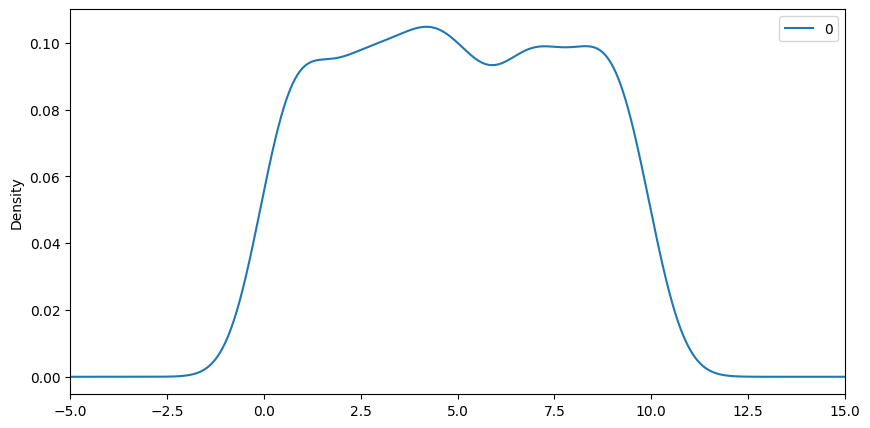

In [ ]:
pd.DataFrame(uniform_data).plot(kind='density',
                                figsize=(10,5),
                                xlim=(-5,15))

In [ ]:
stats.uniform.cdf(4, loc=0, scale=10)      # Cumulative Distribution Function

np.float64(0.4)

In [ ]:
stats.uniform.ppf(0.6, loc=0, scale=10)    # Percent Point Function

np.float64(6.0)

In [ ]:
stats.uniform.pdf(4, loc=0, scale=10)      # Probability Density Function

np.float64(0.1)

In [19]:
for x in range(-1,12,2):
    print(f'PDF at {x}: ', end='')
    print (stats.uniform.pdf(x, loc=0, scale=10), '\n')

PDF at -1: 0.0 

PDF at 1: 0.1 

PDF at 3: 0.1 

PDF at 5: 0.1 

PDF at 7: 0.1 

PDF at 9: 0.1 

PDF at 11: 0.0 



In [4]:
# Set the seed to an arbitrary value and always get the same random numbers

random.seed(12)  # Set the seed to an arbitrary value

print([random.uniform(0,10) for x in range(4)])

random.seed(12)  # Set the seed to the same value

print([random.uniform(0,10) for x in range(4)])

[4.7457067868854805, 6.574725026572553, 6.664104711248381, 1.4260035292536777]
[4.7457067868854805, 6.574725026572553, 6.664104711248381, 1.4260035292536777]


The Normal Distribution

In [ ]:
prob_under_minus1 = stats.norm.cdf(-1, loc=0, scale=1)

prob_over_1 = 1 - stats.norm.cdf( 1, loc=0 , scale=1)

between_prob = stats.norm.cdf(1, loc=0, scale=1) - stats.norm.cdf(-1, loc=0, scale=1)   # OR: 1 - (prob_under_minus1 + prob_over_1)  


print(prob_under_minus1, prob_over_1, between_prob)

0.15865525393145707 0.15865525393145707 0.6826894921370859


In [60]:
stats.norm.cdf(1.96, loc=0, scale=1) 

np.float64(0.9750021048517795)

Text(1.4, 0.03, '0.159')

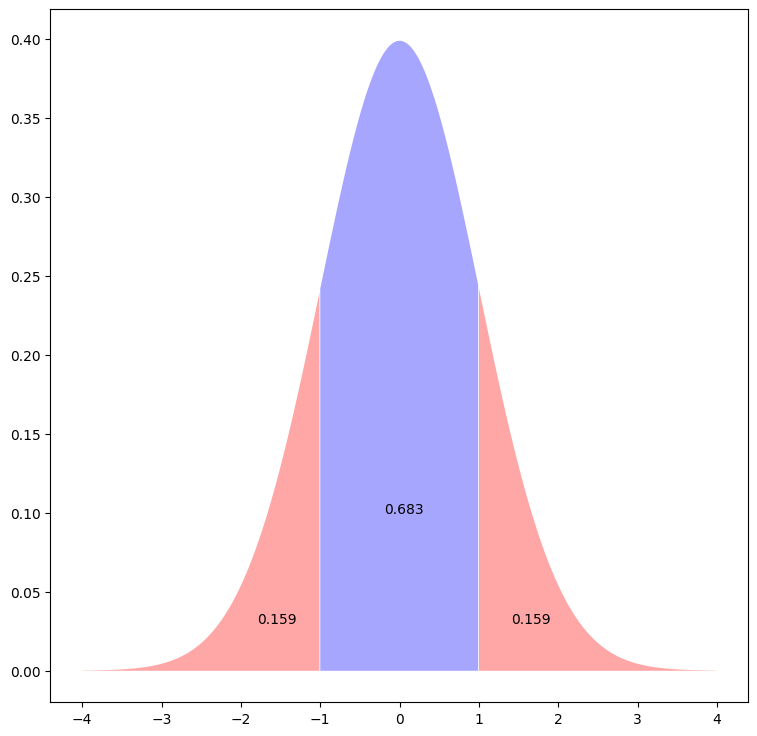

In [ ]:
# Plot normal distribution areas

plt.rcParams["figure.figsize"] = (9,9)
                                  
plt.fill_between(x=np.arange(-4,-1,0.01), 
                 y1= stats.norm.pdf(np.arange(-4,-1,0.01)) ,
                 facecolor='red',
                 alpha=0.35)

plt.fill_between(x=np.arange(1,4,0.01), 
                 y1= stats.norm.pdf(np.arange(1,4,0.01)) ,
                 facecolor='red',
                 alpha=0.35)

plt.fill_between(x=np.arange(-1,1,0.01), 
                 y1= stats.norm.pdf(np.arange(-1,1,0.01)) ,
                 facecolor='blue',
                 alpha=0.35)

plt.text(x=-1.8, y=0.03, s= round(prob_under_minus1,3))
plt.text(x=-0.2, y=0.1, s= round(between_prob,3))
plt.text(x=1.4, y=0.03, s= round(prob_over_1,3))

In [66]:
print(stats.norm.ppf(0.025))

print(stats.norm.ppf(0.975))

-1.9599639845400545
1.959963984540054


The Binomial Distribution

In [24]:
# The Binomial distribution is a disccrete probability distribution that models the outcome of a given number of random trails of some experiment or event.

# The Binomial is defined by two parameters: the probability of success in any given trial (p) and the number of trials (n).

# The Binomial distribution tells you how likely it is to achieve a given number of successes in n trials of the experiment.

col_0   1   2    3    4    5    6    7   8   9
row_0                                         
Counts  7  39  121  226  230  201  129  35  12


<Axes: ylabel='Frequency'>

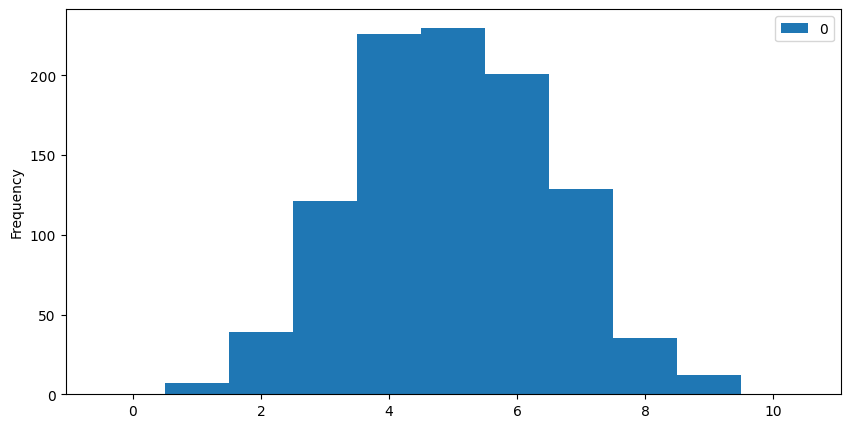

In [3]:
fair_coin_flips = stats.binom.rvs(n=10,        # Number of trials
                                  p=0.5,       # Probability of success on each trial           
                                  size=1000)    # Number of random variables to generate

cross_tab = pd.crosstab(index = 'Counts', columns = fair_coin_flips)        

print(cross_tab)

pd.DataFrame(fair_coin_flips).plot(kind='hist', range=(-0.5,10.5), bins=11, figsize=(10,5)) 

In [11]:
stats.binom.rvs(n=10, p=0.5, size = 1)

array([3])

array([[<Axes: title={'center': '0'}>]], dtype=object)

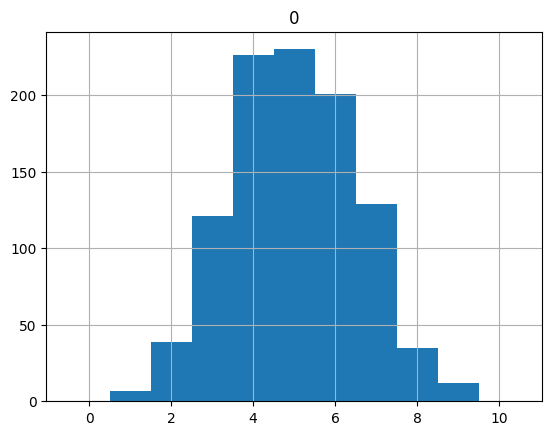

In [4]:
pd.DataFrame(fair_coin_flips).hist(range=(-0.5,10.5), bins=11)

col_0   4   5   6    7    8    9    10
row_0                                 
Counts   9  23  89  202  297  256  124


<Axes: ylabel='Frequency'>

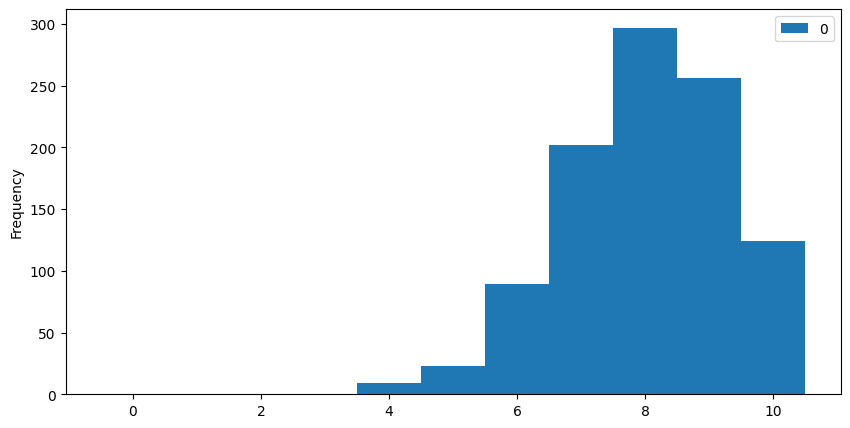

In [8]:
fair_coin_flips = stats.binom.rvs(n=10,        # Number of trials
                                  p=0.8,       # Probability of success on each trial           
                                  size=1000)    # Number of random variables to generate

cross_tab = pd.crosstab(index = 'Counts', columns = fair_coin_flips)        

print(cross_tab)

pd.DataFrame(fair_coin_flips).plot(kind='hist', range=(-0.5,10.5), bins=11, figsize=(10,5)) 

In [16]:
# The cdf() function lets us check the probability os achieving a nukber of successes withina certain range:

stats.binom.cdf(k=5,                        # Probability of k = 5 successes OR LESS
                n=10,                       # With 10 flips
                p=0.8)                      # And succes probability of 0.8

np.float64(0.03279349759999996)

In [17]:
1 - stats.binom.cdf(k=8,                    # Probability of k = 9 successes OR MORE
                n=10,                       # With 10 flips
                p=0.8)                      # And succes probability of 0.8

np.float64(0.37580963840000026)

In [18]:
# For continuous probability density functions, we use the pdf() function to check the probability density at a given x value.
# For discretes distribuition (like the Binomial), we use the pmf() function (probability mass function) to check the mass (proportion of observations) at a given number of successes k:

stats.binom.pmf(k=5,
                n=10,
                p=0.5)

np.float64(0.24609375)

In [22]:
stats.binom.pmf(k=1,
                n=10,
                p=0.5)

np.float64(0.009765625000000003)

The Geometric and Exponential Distributions

In [ ]:
# The Geometric and Exponential Distributions model the time it takes for an event to occur. 

# The Geometric Distribution is discrete and models the number of trials it takes to achieve a succes in repeated experiments with a given probability of success p.

# The Exponential Distribution is a continuous analog of the geometric distribution and models the amount of time you have to wait before an event occurs given a certain occurrence rate (lambda).

col_0     1    2    3   4   5   6   7  8  9
row_0                                      
counts  506  250  118  63  33  14  11  4  1


array([[<Axes: title={'center': '0'}>]], dtype=object)

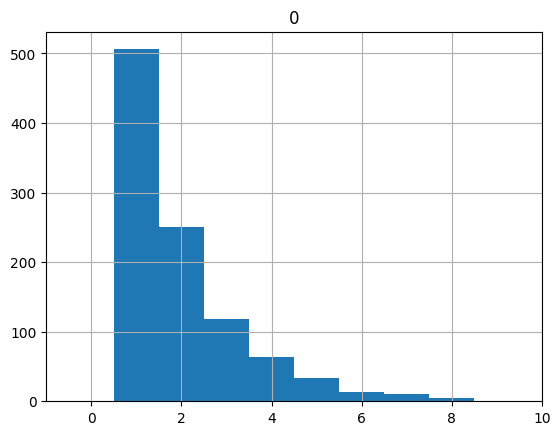

In [ ]:
#GEOMETRIC DISTRIBUTION

# Number of trials it takes to get success (heads) when flipping a fair coin (p=0.5)

flips_till_heads = stats.geom.rvs(size=1000,                    # Generate gemoetric data
                                  p=0.5                         # With success prob of 0.5
                                  )


# Print table of counts
print(pd.crosstab(index = 'counts', columns = flips_till_heads))

pd.DataFrame(flips_till_heads).hist(range = (-0.5, max(flips_till_heads)+0.5),
                                    bins = max(flips_till_heads) + 1
                                    )

In [ ]:
# We use the cdf() function to check the probability of needing a specific number of flips OR LESS/MORE to get a success.


# probability of needing 6 flips or more to get a succes:

first_five = stats.geom.cdf(k=5,                    # Probability of succes in first 5 flips   
                            p=0.5)

1 - first_five                                      # Probability of needing MORE than 5 flips to get success

np.float64(0.03125)

In [ ]:
# We use the pmf() function to check the probability of seeing a specific number offlips before a success.

# Probability of needing exactly 2 flips to get first success:
stats.geom.pmf(k=2,
               p=0.5)



np.float64(0.25)

In [ ]:
# EXPONENTIAL DISTRIBUTION 

# We use de cdf() function to check the probability of waiting a specific amount of time or LESS/MORE before a success occurs.

prob_1 = stats.expon.cdf(x=1,                    # Probability of waiting 1 time unit or LESS)
                         scale=1)                # Average Time until the succes: 1/Arrival rate(lambda)


prob_over_1 = 1 - prob_1                          # Probability of waiting MORE than 1 time unit

print(prob_1, prob_over_1)

0.6321205588285577 0.36787944117144233


Text(1.5, 0.08, '0.368')

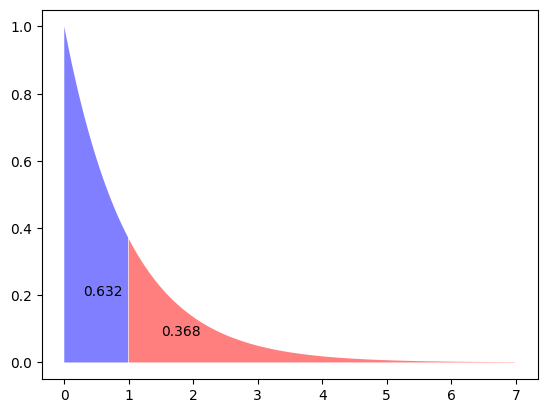

In [76]:
# Ploting the Exponential Distribution

plt.fill_between(x= np.arange(0,1,0.01),
                 y1= stats.expon.pdf(np.arange(0,1,0.01), scale=1),
                 facecolor='blue',
                 alpha = 0.5)

plt.fill_between(x= np.arange(1,7,0.01),
                 y1= stats.expon.pdf(np.arange(1,7,0.01), scale=1),
                 facecolor='red',
                 alpha = 0.5)


plt.text(x=0.3, y=0.2, s= round(prob_1,3))
plt.text(x=1.5, y=0.08, s= round(prob_over_1,3))

In [70]:
# teste2 = stats.expon.pdf(x=200,
#                          scale=1
#                          )

teste2 = stats.expon.pdf(np.arange(0,10,0.5), scale=0.2)

teste2

array([5.00000000e+00, 4.10424993e-01, 3.36897350e-02, 2.76542185e-03,
       2.26999649e-04, 1.86332659e-05, 1.52951160e-06, 1.25549958e-07,
       1.03057681e-08, 8.45948961e-10, 6.94397193e-11, 5.69995927e-12,
       4.67881148e-13, 3.84060234e-14, 3.15255838e-15, 2.58777750e-16,
       2.12417713e-17, 1.74363077e-18, 1.43125929e-19, 1.17484917e-20])

The Poisson Distribution

In [ ]:
# The Poisson Distribution models the probability of seeing a given number of events occur (successes) within a time interval, given a rate of occurrence (lambda).

# The time it takes for the next event to occur follows an Exponential Distribution (with scale = 1/lambda).


col_0     0     1     2    3    4   5  6  7
row_0                                      
Couts  3675  3681  1790  655  160  35  3  1


array([[<Axes: title={'center': '0'}>]], dtype=object)

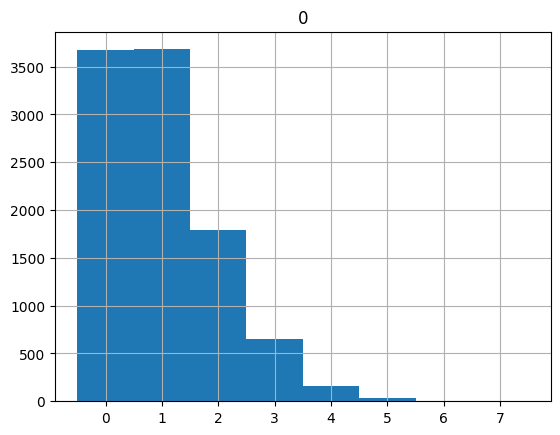

In [95]:
arrival_rate_1 = stats.poisson.rvs(size=10000,              # Generate Poisson data
                                   mu=1)                    # With average rate of 1 event per time unit (lambda = 1)

print(pd.crosstab(index = 'Couts',columns = arrival_rate_1))              


pd.DataFrame(arrival_rate_1).hist(range=(-0.5, max(arrival_rate_1)+0.5), bins=max(arrival_rate_1)+1)

In [ ]:
# The histogram shows that when arrivals are relatively infrequent, it is rare to see more than a couple of arrivals in each time period. 

# When the arrival rate is high, it becomes increasingly rare to see a low number of arrivals and the distribution starts to look more symmetric:

col_0   1   2   3    4    5    6    7     8     9     10  ...   15   16   17  \
row_0                                                     ...                  
Counts   3  21  69  218  386  604  911  1123  1219  1253  ...  334  217  137   

col_0   18  19  20  21  22  23  24  
row_0                               
Counts  80  39  12  14   5   3   1  

[1 rows x 24 columns]


array([[<Axes: title={'center': '0'}>]], dtype=object)

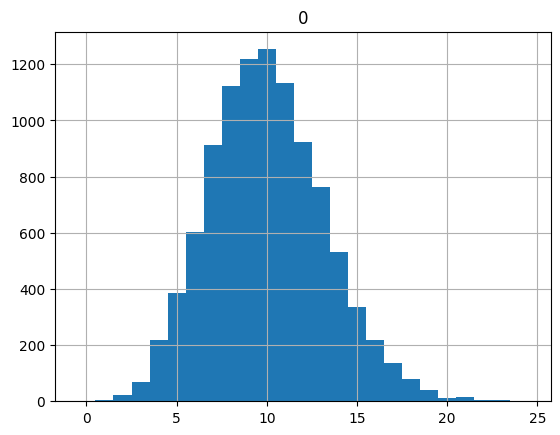

In [ ]:
arrival_rate_10 = stats.poisson.rvs(size = 10000,                               # Generate Poisson data
                                    mu=10)                                      # Average arrival time 10


print(pd.crosstab(index="Counts", columns= arrival_rate_10))


pd.DataFrame(arrival_rate_10).hist( range = (-0.5, max(arrival_rate_10)+0.5),
                                   bins = max(arrival_rate_10)+1)

In [ ]:
# As with other discrete probability distributions, we can use cdf() function to check the probability of achieving more or less than a certain number of successes

# And we user the pmf() function to check the probability of obtaining a specific number of successes:

In [ ]:
stats.poisson.cdf(k=5,              # Check the probability of 5 arrivals OR LESS
                  mu=10)            # With arrival rate of 10



np.float64(0.06708596287903189)

In [15]:
stats.poisson.pmf(k=5,             # Check the probability of EXACTLY 5 arrivals
                  mu=10)            # With arrival rate of 10

np.float64(0.03783327480207079)